# Example Notebook — ASR Robustness Evaluation (Step-by-Step)

## Feel free to create your own notebook, this is just for you to get it started
**Goal:** Evaluate **≥ 5** state-of-the-art ASR models on your own recordings under:
- **Clean** (quiet room)
- **Synthetic additive noise** (2 noise types × 2 SNR levels)
- **Real-world recordings** (2 environments)
- *(optional) Reverberation* (1–2 simulated rooms)
- *(Bonus)* **multilingual/code-mixed speech  or special-population (children, older adults, disorders) evaluation** 

You will compute:
- **WER**, (optional **CER**)
- **Substitutions / Insertions / Deletions** (S/I/D)
- A focused analysis comparing **7 grammatical** vs **3ungrammatical** sentences

> **No model training.** Only inference + evaluation + analysis.


## 0) What you need before running this notebook

### A. Create your 10 sentences
- **7 grammatically correct**
- **3 grammatically incorrect** (intentionally incorrect)

### Optional format: 
Save transcripts into: `project/sentences/ground_truth.csv` with columns:
- `sentence_id` (s01 … s10)
- `text` (the ground truth)
- `is_grammatical` (1 for grammatical, 0 for ungrammatical)

#### Record audio (your own voice)
Record and Save into:

- `project/audio/clean/s01.wav ... s10.wav`
- `project/audio/real/env1/s01.wav ... s10.wav`
- `project/audio/real/env2/s01.wav ... s10.wav`

**Real-world environment examples (choose any):**
- walking outdoors on a street 
- cafeteria / restaurant ambience
- inside a moving car / bus
- cooking at home (fan + utensils)
- quiet whisper/soft speech scenario 

✅ First run models on **as-recorded** real-world audio (no enhancement yet). Enhancement is Notebook 02.


## 1) Install dependencies (run once)

If you use a fresh environment (e.g., Colab):

```bash
pip install -U transformers accelerate torchaudio soundfile librosa jiwer pandas numpy scipy matplotlib
pip install -U openai-whisper
```

Notes:
- Whisper requires `ffmpeg` (often preinstalled on Colab; otherwise install system ffmpeg).
- Some HF models may require GPU for reasonable speed.


In [2]:
import os, re, math, json
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import matplotlib.pyplot as plt

# from jiwer import compute_measures, cer
from jiwer import cer
from scipy.signal import butter, sosfilt
from scipy.signal import fftconvolve

plt.rcParams["figure.figsize"] = (10, 4)


## 2) Configure paths (edit PROJECT_ROOT if needed)


In [3]:
PROJECT_ROOT = "./project"

GT_PATH = os.path.join(PROJECT_ROOT, "sentences", "ground_truth.csv")

CLEAN_DIR = os.path.join(PROJECT_ROOT, "audio", "clean")
REAL_DIR  = os.path.join(PROJECT_ROOT, "audio", "real")        # contains env1/, env2/
SYN_DIR   = os.path.join(PROJECT_ROOT, "audio", "synthetic")   # will be created

OUT_DIR   = os.path.join(PROJECT_ROOT, "outputs")
MET_DIR   = os.path.join(OUT_DIR, "metrics")
FIG_DIR   = os.path.join(OUT_DIR, "figures")

for d in [SYN_DIR, OUT_DIR, MET_DIR, FIG_DIR]:
    os.makedirs(d, exist_ok=True)

SR = 16000


## 3) Load ground truth and validate formatting


In [4]:
gt = pd.read_csv(GT_PATH)
required_cols = {"sentence_id","text","is_grammatical"}
missing = required_cols - set(gt.columns)
if missing:
    raise ValueError(f"ground_truth.csv missing columns: {missing}")

gt["sentence_id"] = gt["sentence_id"].astype(str)
gt["is_grammatical"] = gt["is_grammatical"].astype(int)

gt.sort_values("sentence_id").head(10)


,sentence_id,text,is_grammatical
0,s01,I go to the University of Southern California,1
1,s02,I am taking a speech AI course,1
2,s03,I am taking a machine learning systems class,1
3,s04,I am taking an introduction to philosophy gen ed,1
4,s05,I am doing a project on anti spoofing,1
5,s06,Computer architecure is one of my academic int...,1
6,s07,My graduation will be in May of this year,1
7,s08,Spider eye lamb population,0
8,s09,Connor Bryce Jude Ryan Barclay,0
9,s10,incompetent overpromise underdeliver,0


## 4) Audio helpers + sanity checks

This section checks:
- all s01..s10 exist in clean
- real env folders contain the same sentence ids


In [4]:
def list_wavs(folder):
    if not os.path.exists(folder):
        return []
    return sorted([f for f in os.listdir(folder) if f.lower().endswith(".wav")])

def expect_sentence_ids(files):
    return sorted([os.path.splitext(f)[0] for f in files])

clean_files = list_wavs(CLEAN_DIR)
print("Clean wav count:", len(clean_files))
print("Clean IDs:", expect_sentence_ids(clean_files))

# Check real envs
if os.path.exists(REAL_DIR):
    envs = sorted([d for d in os.listdir(REAL_DIR) if os.path.isdir(os.path.join(REAL_DIR,d))])
else:
    envs = []
print("Real environments found:", envs)

for env in envs:
    files = list_wavs(os.path.join(REAL_DIR, env))
    print(env, "count:", len(files), "IDs:", expect_sentence_ids(files)[:3], "...")

# Quick consistency check
gt_ids = sorted(gt["sentence_id"].tolist())
clean_ids = expect_sentence_ids(clean_files)
if gt_ids != clean_ids:
    print("WARNING: ground_truth sentence_ids and clean wav IDs do not match.")


Clean wav count: 10
Clean IDs: ['s01', 's02', 's03', 's04', 's05', 's06', 's07', 's08', 's09', 's10']
Real environments found: ['env1', 'env2']
env1 count: 10 IDs: ['s01', 's02', 's03'] ...
env2 count: 10 IDs: ['s01', 's02', 's03'] ...


## 5) Synthetic additive noise generation (2 noise types × 2 SNR levels)

**You must use 2 noise types** (default: white + pink/traffic placeholder).

Options:
- **White noise** (generated)
- **Pink noise** (generated, proxy for “realistic” low-frequency noise)
- **Traffic noise file**: you may provide `project/noises/traffic.wav` (recommended)

SNR levels:
- **20 dB** (mild noise)
- **0 dB** (moderate noise)

Output folders created:
- `project/audio/synthetic/noise_white_snr20/`
- `project/audio/synthetic/noise_white_snr10/`
- `project/audio/synthetic/noise_traffic_snr20/` ... etc


In [5]:
NOISE_DIR = os.path.join(PROJECT_ROOT, "noises")
TRAFFIC_WAV = os.path.join(NOISE_DIR, "traffic.wav")  # optional file you can add

SNR_LEVELS = [20, 10]
NOISE_TYPES = ["white", "traffic"]  # keep 2 types; you can replace traffic with pink if you want

def load_wav(path, sr=SR):
    y, _ = librosa.load(path, sr=sr, mono=True)
    return y.astype(np.float32)

def save_wav(path, y, sr=SR):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    sf.write(path, y, sr)

def rms(x):
    return float(np.sqrt(np.mean(x**2) + 1e-12))

def match_len(x, n):
    if len(x) == n:
        return x
    if len(x) > n:
        return x[:n]
    return np.pad(x, (0, n-len(x)))

def white_noise(n):
    x = np.random.randn(n).astype(np.float32)
    x = x / (rms(x) + 1e-12)
    return x

def pink_noise(n):
    # simple 1/f noise using FFT shaping
    x = np.random.randn(n).astype(np.float32)
    X = np.fft.rfft(x)
    freqs = np.linspace(1, len(X), len(X))
    X = X / freqs
    y = np.fft.irfft(X, n=n).astype(np.float32)
    y = y / (rms(y) + 1e-12)
    return y

def add_noise_snr(clean, noise, snr_db):
    noise = match_len(noise, len(clean))
    clean_p = np.mean(clean**2) + 1e-12
    noise_p = np.mean(noise**2) + 1e-12
    desired_noise_p = clean_p / (10**(snr_db/10))
    scale = math.sqrt(desired_noise_p / noise_p)
    return (clean + scale*noise).astype(np.float32)

def get_noise(noise_type, n):
    if noise_type == "white":
        return white_noise(n)
    if noise_type == "traffic":
        if os.path.exists(TRAFFIC_WAV):
            y = load_wav(TRAFFIC_WAV)
            if len(y) < n:
                reps = int(np.ceil(n/len(y)))
                y = np.tile(y, reps)
            y = y[:n]
            y = y / (rms(y) + 1e-12)
            return y.astype(np.float32)
        # fallback if traffic.wav not provided:
        return pink_noise(n)
    raise ValueError("Unknown noise_type")

def generate_synthetic_noisy():
    for f in clean_files:
        sid = os.path.splitext(f)[0]
        y = load_wav(os.path.join(CLEAN_DIR, f))

        for nt in NOISE_TYPES:
            noise = get_noise(nt, len(y))
            for snr in SNR_LEVELS:
                yn = add_noise_snr(y, noise, snr_db=snr)
                out_dir = os.path.join(SYN_DIR, f"noise_{nt}_snr{snr}")
                save_wav(os.path.join(out_dir, f"{sid}.wav"), yn)

generate_synthetic_noisy()
print("Synthetic noisy audio generated in:", SYN_DIR)


c:\Users\K\Documents\usc\ee519\EE519-HW2\asr_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Synthetic noisy audio generated in: ./project\audio\synthetic


## 6) Optional: Reverberation (lightweight)

If you want an **optional** reverb experiment:
- Apply 1–2 RT60 settings (e.g., 0.3s small room, 0.8s large room)

Outputs:
- `project/audio/synthetic/reverb_small/`
- `project/audio/synthetic/reverb_large/`

If you skip this section, that's OK.


In [ ]:
DO_REVERB = False  # set True if you want the optional reverb experiment

def synthetic_rir(sr, rt60=0.3, length_s=1.0):
    n = int(sr*length_s)
    t = np.arange(n) / sr
    decay = np.exp(-6.91 * t / max(rt60, 1e-3))
    rir = np.random.randn(n).astype(np.float32) * decay.astype(np.float32)
    rir[0] += 1.0  # direct impulse
    rir = rir / (np.max(np.abs(rir)) + 1e-12)
    return rir.astype(np.float32)

def apply_reverb(y, sr, rt60):
    rir = synthetic_rir(sr, rt60=rt60, length_s=1.0)
    out = fftconvolve(y, rir, mode="full")[:len(y)]
    out = out / (np.max(np.abs(out)) + 1e-12)
    return out.astype(np.float32)

if DO_REVERB:
    for f in clean_files:
        sid = os.path.splitext(f)[0]
        y = load_wav(os.path.join(CLEAN_DIR, f))
        y_small = apply_reverb(y, SR, rt60=0.3)
        y_large = apply_reverb(y, SR, rt60=0.8)
        save_wav(os.path.join(SYN_DIR, "reverb_small", f"{sid}.wav"), y_small)
        save_wav(os.path.join(SYN_DIR, "reverb_large", f"{sid}.wav"), y_large)
    print("Reverb generated.")
else:
    print("Skipping reverb (set DO_REVERB=True to run).")


## 7) Index the dataset (clean + synthetic + real)

We build a table with columns:
- split: clean / synthetic / real
- condition: clean OR noise_* OR reverb_* OR env1/env2
- sentence_id: s01..s10
- audio_path


In [6]:
def index_split(split, base_dir, is_flat=False):
    rows = []
    if is_flat:
        for f in list_wavs(base_dir):
            sid = os.path.splitext(f)[0]
            rows.append({"split":split, "condition":split, "sentence_id":sid, "audio_path":os.path.join(base_dir,f)})
        return rows

    if not os.path.exists(base_dir):
        return rows
    for cond in sorted(os.listdir(base_dir)):
        cond_dir = os.path.join(base_dir, cond)
        if not os.path.isdir(cond_dir):
            continue
        for f in list_wavs(cond_dir):
            sid = os.path.splitext(f)[0]
            rows.append({"split":split, "condition":cond, "sentence_id":sid, "audio_path":os.path.join(cond_dir,f)})
    return rows

dataset_rows = []
dataset_rows += index_split("clean", CLEAN_DIR, is_flat=True)
dataset_rows += index_split("synthetic", SYN_DIR, is_flat=False)
dataset_rows += index_split("real", REAL_DIR, is_flat=False)

dataset = pd.DataFrame(dataset_rows)
dataset.head(), dataset["split"].value_counts()


(   split condition sentence_id                     audio_path
 0  clean     clean         s01  ./project\audio\clean\s01.wav
 1  clean     clean         s02  ./project\audio\clean\s02.wav
 2  clean     clean         s03  ./project\audio\clean\s03.wav
 3  clean     clean         s04  ./project\audio\clean\s04.wav
 4  clean     clean         s05  ./project\audio\clean\s05.wav,
 split
 synthetic    40
 real         20
 clean        10
 Name: count, dtype: int64)

## 8) Configure your ≥ 5 ASR models

Recommended starter set:
- **Whisper** sizes (tiny/base/small/medium/large)
- **Hugging Face** ASR pipelines (wav2vec2 / conformer / etc.)


> Tip: Start with 1 model to test pipeline, then expand to 5.


In [9]:
# ---- Whisper wrapper ----
def transcribe_whisper(model_size, audio_path):
    import whisper
    model = whisper.load_model(model_size)
    out = model.transcribe(audio_path)
    return (out.get("text","") or "").strip()

# ---- HF wrapper ----
def build_hf_asr(model_id, device=-1):
    from transformers import pipeline
    return pipeline(
        "automatic-speech-recognition",
        model=model_id,
        device=device,
        chunk_length_s=20,
        stride_length_s=(4, 2),
    )

def transcribe_hf(pipe, audio_path):
    out = pipe(audio_path)
    if isinstance(out, dict) and "text" in out:
        return out["text"].strip()
    return str(out).strip()

DEVICE = 0  # set 0 if you have GPU

ASR_MODELS = [
    {"name":"whisper_base", "type":"whisper", "id":"base"},
    {"name":"whisper_small", "type":"whisper", "id":"small"},
    {"name":"wav2vec2_960h", "type":"hf", "id":"facebook/wav2vec2-base-960h"},
    # TODO: add at least 2 more models (hf or whisper)
    {"name":"hubert_large_ls960", "type":"hf", "id":"facebook/hubert-large-ls960-ft"},
    {"name":"conformer_large_960h", "type":"hf","id":"facebook/wav2vec2-conformer-rel-pos-large-960h-ft"}
]

print("Configured models:", [m["name"] for m in ASR_MODELS])


Configured models: ['whisper_base', 'whisper_small', 'wav2vec2_960h', 'hubert_large_ls960', 'conformer_large_960h']


## 9) Run ASR inference

This produces a `results` DataFrame with:
- model, split, condition, sentence_id
- ref (ground truth), hyp (prediction)
- WER/CER/S/I/D


### Note

compute_measures was causing me tons of issue so I used an LLM to generate a work around.

In [10]:
# --- fallback Levenshtein (works for lists/strings) ---
def _levenshtein_ops(a_tokens, b_tokens):
    """
    Compute edit distance DP and backtrace to count
    substitutions (S), insertions (I), deletions (D), and hits (H).
    a_tokens: list (reference tokens)
    b_tokens: list (hypothesis tokens)
    returns dict with keys: wer, substitutions, insertions, deletions, hits
    """
    n = len(a_tokens)
    m = len(b_tokens)
    # dp matrix: cost
    dp = [[0] * (m + 1) for _ in range(n + 1)]
    # backtrace ops: 0 = match/subst, 1 = del (from a), 2 = ins (from b)
    for i in range(1, n + 1):
        dp[i][0] = i
    for j in range(1, m + 1):
        dp[0][j] = j

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = 0 if a_tokens[i - 1] == b_tokens[j - 1] else 1
            dp[i][j] = min(
                dp[i - 1][j] + 1,          # deletion
                dp[i][j - 1] + 1,          # insertion
                dp[i - 1][j - 1] + cost    # substitution / match
            )

    # backtrace to count ops
    i, j = n, m
    S = I = D = H = 0
    while i > 0 or j > 0:
        if i > 0 and j > 0 and dp[i][j] == dp[i - 1][j - 1] and a_tokens[i - 1] == b_tokens[j - 1]:
            H += 1
            i -= 1; j -= 1
        elif i > 0 and j > 0 and dp[i][j] == dp[i - 1][j - 1] + 1:
            S += 1
            i -= 1; j -= 1
        elif i > 0 and dp[i][j] == dp[i - 1][j] + 1:
            D += 1
            i -= 1
        elif j > 0 and dp[i][j] == dp[i][j - 1] + 1:
            I += 1
            j -= 1
        else:
            # fallback to avoid infinite loop
            # treat remaining as deletes/ins
            if i > 0:
                D += i
                i = 0
            if j > 0:
                I += j
                j = 0

    wer = (S + I + D) / max(1, n)  # avoid div by zero
    return {"wer": wer, "substitutions": S, "insertions": I, "deletions": D, "hits": H}

# --- optional char-level CER fallback ---
def _cer_fallback(ref, hyp):
    # basic Levenshtein distance on characters -> CER = edits / len(ref_chars)
    a = list(ref)
    b = list(hyp)
    n = len(a); m = len(b)
    dp = [[0] * (m + 1) for _ in range(n + 1)]
    for i in range(1, n + 1): dp[i][0] = i
    for j in range(1, m + 1): dp[0][j] = j
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = 0 if a[i-1] == b[j-1] else 1
            dp[i][j] = min(dp[i-1][j] + 1, dp[i][j-1] + 1, dp[i-1][j-1] + cost)
    edits = dp[n][m]
    return edits / max(1, n)

# --- safe compute_metrics wrapper ---
def compute_metrics(ref, hyp):
    """
    Try to use existing compute_measures (jiwer). If it raises NotImplementedError
    (e.g., due to rapidfuzz platform issue), fallback to local DP implementation.
    """
    # try:
    #     m = compute_measures(ref, hyp)  # jiwer's function
    #     return {
    #         "WER": m["wer"],
    #         "CER": cer(ref, hyp),            # keep your existing CER if available
    #         "S": m["substitutions"],
    #         "I": m["insertions"],
    #         "D": m["deletions"],
    #         "H": m["hits"],
    #     }
    # except NotImplementedError:
    # Word-level metrics fallback (use tokenization similar to jiwer default)
    ref_tokens = ref.split() if isinstance(ref, str) else list(ref)
    hyp_tokens = hyp.split() if isinstance(hyp, str) else list(hyp)
    m = _levenshtein_ops(ref_tokens, hyp_tokens)
    # CER fallback if your cer() function unexpectedly fails
    try:
        cer_val = cer(ref, hyp)
    except Exception:
        cer_val = _cer_fallback(ref, hyp)
    return {
        "WER": m["wer"],
        "CER": cer_val,
        "S": m["substitutions"],
        "I": m["insertions"],
        "D": m["deletions"],
        "H": m["hits"],
    }

In [11]:
def normalize_text(s):
    s = (s or "").lower().strip()
    s = re.sub(r"[^a-z0-9' ]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

gt_map = {r.sentence_id: r.text for r in gt.itertuples(index=False)}
gram_map = {r.sentence_id: int(r.is_grammatical) for r in gt.itertuples(index=False)}

# def compute_metrics(ref, hyp):
#     m = compute_measures(ref, hyp)
#     return {
#         "WER": m["wer"],
#         "CER": cer(ref, hyp),
#         "S": m["substitutions"],
#         "I": m["insertions"],
#         "D": m["deletions"],
#         "H": m["hits"],
#     }

def run_asr(dataset_df, models):
    # build hf pipelines once
    hf = {}
    for m in models:
        if m["type"] == "hf":
            hf[m["name"]] = build_hf_asr(m["id"], device=DEVICE)

    rows = []
    for m in models:
        print(m)
        for r in dataset_df.itertuples(index=False):
            ref = gt_map[r.sentence_id]
            if m["type"] == "whisper":
                hyp = transcribe_whisper(m["id"], r.audio_path)
            else:
                hyp = transcribe_hf(hf[m["name"]], r.audio_path)

            ref_n = normalize_text(ref)
            hyp_n = normalize_text(hyp)

            met = compute_metrics(ref_n, hyp_n)
            rows.append({
                "model": m["name"],
                "split": r.split,
                "condition": r.condition,
                "sentence_id": r.sentence_id,
                "is_grammatical": gram_map[r.sentence_id],
                "audio_path": r.audio_path,
                "ref": ref,
                "hyp": hyp,
                **met
            })
    return pd.DataFrame(rows)

# Optional: quick test subset
# ds = dataset.query("split=='clean'").copy()
ds = dataset.copy()

# Uncomment to run:
# results = run_asr(ds, ASR_MODELS)
# results.to_csv(os.path.join(MET_DIR, "results_all.csv"), index=False)
# results.head()
print("Ready. Uncomment the run block to execute ASR.")


Ready. Uncomment the run block to execute ASR.


In [ ]:
ind = 0
mname = ASR_MODELS[ind]["name"]
results = run_asr(ds, [ASR_MODELS[ind]])
results.to_csv(os.path.join(MET_DIR, f"{mname}_results.csv"), index=False)
results.head()

{'name': 'whisper_base', 'type': 'whisper', 'id': 'base'}


,model,split,condition,sentence_id,is_grammatical,audio_path,ref,hyp,WER,CER,S,I,D,H
0,whisper_base,clean,clean,s01,1,./project\audio\clean\s01.wav,I go to the University of Southern California,I go to the University of Southern California.,0.000,0.000000,0,0,0,8
1,whisper_base,clean,clean,s02,1,./project\audio\clean\s02.wav,I am taking a speech AI course,I am taking a speech AI course.,0.000,0.000000,0,0,0,7
2,whisper_base,clean,clean,s03,1,./project\audio\clean\s03.wav,I am taking a machine learning systems class,I am taking a machine learning systems class.,0.000,0.000000,0,0,0,8
3,whisper_base,clean,clean,s04,1,./project\audio\clean\s04.wav,I am taking an introduction to philosophy gen ed,I am taking an introduction to philosophy gen ed.,0.000,0.000000,0,0,0,9
4,whisper_base,clean,clean,s05,1,./project\audio\clean\s05.wav,I am doing a project on anti spoofing,I am doing a project on anti-spooping.,0.125,0.027027,1,0,0,7


In [16]:
ind = 1
mname = ASR_MODELS[ind]["name"]
results = run_asr(ds, [ASR_MODELS[ind]])
results.to_csv(os.path.join(MET_DIR, f"{mname}_results.csv"), index=False)
results.head()

{'name': 'whisper_small', 'type': 'whisper', 'id': 'small'}


,model,split,condition,sentence_id,is_grammatical,audio_path,ref,hyp,WER,CER,S,I,D,H
0,whisper_small,clean,clean,s01,1,./project\audio\clean\s01.wav,I go to the University of Southern California,I go to the University of Southern California.,0.000000,0.000000,0,0,0,8
1,whisper_small,clean,clean,s02,1,./project\audio\clean\s02.wav,I am taking a speech AI course,I am taking a speech AI course.,0.000000,0.000000,0,0,0,7
2,whisper_small,clean,clean,s03,1,./project\audio\clean\s03.wav,I am taking a machine learning systems class,I am taking a machine learning systems class.,0.000000,0.000000,0,0,0,8
3,whisper_small,clean,clean,s04,1,./project\audio\clean\s04.wav,I am taking an introduction to philosophy gen ed,"I am taking an introduction to philosophy, Jea...",0.111111,0.041667,1,0,0,8
4,whisper_small,clean,clean,s05,1,./project\audio\clean\s05.wav,I am doing a project on anti spoofing,I am doing a project on anti spoofing.,0.000000,0.000000,0,0,0,8


In [17]:
ind = 2
mname = ASR_MODELS[ind]["name"]
results = run_asr(ds, [ASR_MODELS[ind]])
results.to_csv(os.path.join(MET_DIR, f"{mname}_results.csv"), index=False)
results.head()

Loading weights: 100%|██████████| 212/212 [00:00<00:00, 641.35it/s, Materializing param=wav2vec2.feature_projection.projection.weight]                         
Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-960h
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'name': 'wav2vec2_960h', 'type': 'hf', 'id': 'facebook/wav2vec2-base-960h'}


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


,model,split,condition,sentence_id,is_grammatical,audio_path,ref,hyp,WER,CER,S,I,D,H
0,wav2vec2_960h,clean,clean,s01,1,./project\audio\clean\s01.wav,I go to the University of Southern California,I GO TO THE UNIVERSITY OF SOUTHERN CALIFORNIA,0.000000,0.000000,0,0,0,8
1,wav2vec2_960h,clean,clean,s02,1,./project\audio\clean\s02.wav,I am taking a speech AI course,I AM TAKING A SPEECH A I COARSE,0.428571,0.066667,2,1,0,5
2,wav2vec2_960h,clean,clean,s03,1,./project\audio\clean\s03.wav,I am taking a machine learning systems class,I AM TAKING A MACHINE LEARNING SYSTEM'S CLASS,0.125000,0.022727,1,0,0,7
3,wav2vec2_960h,clean,clean,s04,1,./project\audio\clean\s04.wav,I am taking an introduction to philosophy gen ed,I AM TAKING AN INTRODUCTION TO PHILOSOPHY JANED,0.222222,0.062500,1,0,1,7
4,wav2vec2_960h,clean,clean,s05,1,./project\audio\clean\s05.wav,I am doing a project on anti spoofing,I AM DOING A PROJECT ON ANTI SPOOFING,0.000000,0.000000,0,0,0,8


In [18]:
ind = 3
mname = ASR_MODELS[ind]["name"]
results = run_asr(ds, [ASR_MODELS[ind]])
results.to_csv(os.path.join(MET_DIR, f"{mname}_results.csv"), index=False)
results.head()

Loading weights: 100%|██████████| 424/424 [00:00<00:00, 736.82it/s, Materializing param=lm_head.weight]                                                      


{'name': 'hubert_large_ls960', 'type': 'hf', 'id': 'facebook/hubert-large-ls960-ft'}


,model,split,condition,sentence_id,is_grammatical,audio_path,ref,hyp,WER,CER,S,I,D,H
0,hubert_large_ls960,clean,clean,s01,1,./project\audio\clean\s01.wav,I go to the University of Southern California,I GO TO THE UNIVERSITY OF SOUTHERN CALIFORNIA,0.000000,0.000000,0,0,0,8
1,hubert_large_ls960,clean,clean,s02,1,./project\audio\clean\s02.wav,I am taking a speech AI course,I AM TAKING A SPEECH A I COURSE,0.285714,0.033333,1,1,0,6
2,hubert_large_ls960,clean,clean,s03,1,./project\audio\clean\s03.wav,I am taking a machine learning systems class,I AM TAKING A MACHINE LEARNING SYSTEM'S CLASS,0.125000,0.022727,1,0,0,7
3,hubert_large_ls960,clean,clean,s04,1,./project\audio\clean\s04.wav,I am taking an introduction to philosophy gen ed,I AM TAKING AN INTRODUCTION TO PHILOSOPHY JANED,0.222222,0.062500,1,0,1,7
4,hubert_large_ls960,clean,clean,s05,1,./project\audio\clean\s05.wav,I am doing a project on anti spoofing,I AM DOING A PROJECT ON ANTI SPOOFING,0.000000,0.000000,0,0,0,8


In [19]:
ind = 4
mname = ASR_MODELS[ind]["name"]
results = run_asr(ds, [ASR_MODELS[ind]])
results.to_csv(os.path.join(MET_DIR, f"{mname}_results.csv"), index=False)
results.head()

Loading weights: 100%|██████████| 928/928 [00:01<00:00, 677.70it/s, Materializing param=wav2vec2_conformer.masked_spec_embed]                                            


{'name': 'conformer_large_960h', 'type': 'hf', 'id': 'facebook/wav2vec2-conformer-rel-pos-large-960h-ft'}


,model,split,condition,sentence_id,is_grammatical,audio_path,ref,hyp,WER,CER,S,I,D,H
0,conformer_large_960h,clean,clean,s01,1,./project\audio\clean\s01.wav,I go to the University of Southern California,I GO TO THE UNIVERSITY OF SOUTHERN CALIFORNIA,0.000000,0.000000,0,0,0,8
1,conformer_large_960h,clean,clean,s02,1,./project\audio\clean\s02.wav,I am taking a speech AI course,I AM TAKING A SPEECH A I COURSE,0.285714,0.033333,1,1,0,6
2,conformer_large_960h,clean,clean,s03,1,./project\audio\clean\s03.wav,I am taking a machine learning systems class,I AM TAKING A MACHINE LEARNING SYSTEM'S CLASS,0.125000,0.022727,1,0,0,7
3,conformer_large_960h,clean,clean,s04,1,./project\audio\clean\s04.wav,I am taking an introduction to philosophy gen ed,I AM TAKING AN INTRODUCTION TO PHILOSOPHY JANET,0.222222,0.083333,1,0,1,7
4,conformer_large_960h,clean,clean,s05,1,./project\audio\clean\s05.wav,I am doing a project on anti spoofing,I AM DOING A PROJECT ON ANTI SPOOFING,0.000000,0.000000,0,0,0,8


## 10) Summaries and plots (after you have `results`)

You should produce:
1) WER by condition (per model)
2) Clean vs synthetic vs real comparisons
3) Grammatical vs ungrammatical comparisons


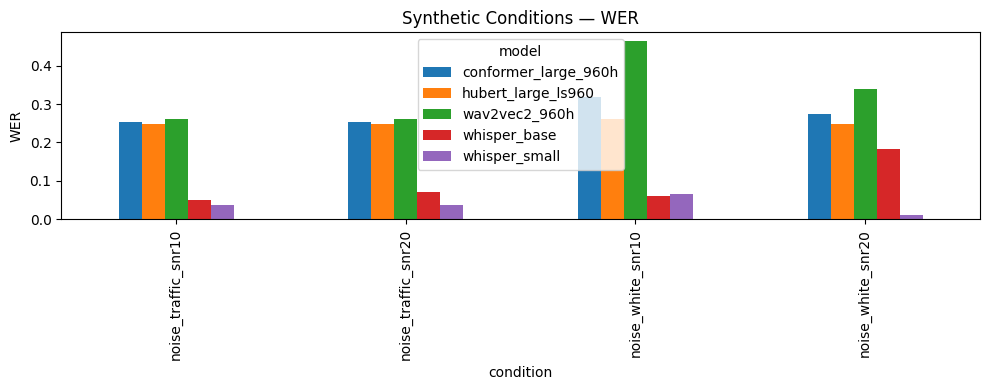

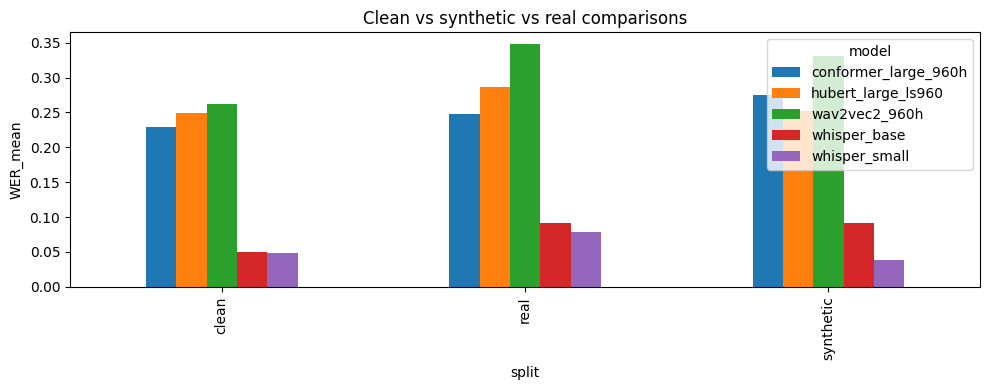

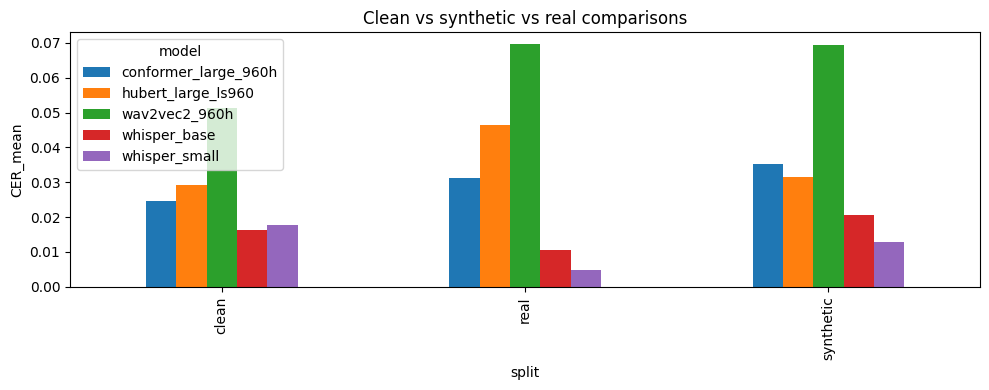

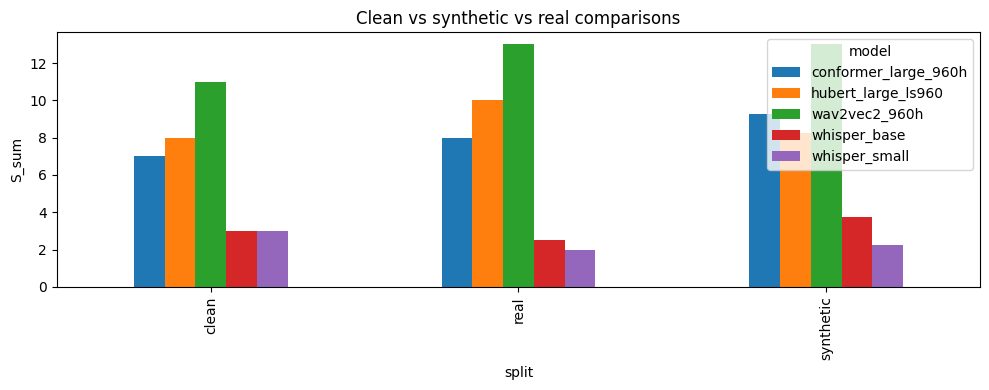

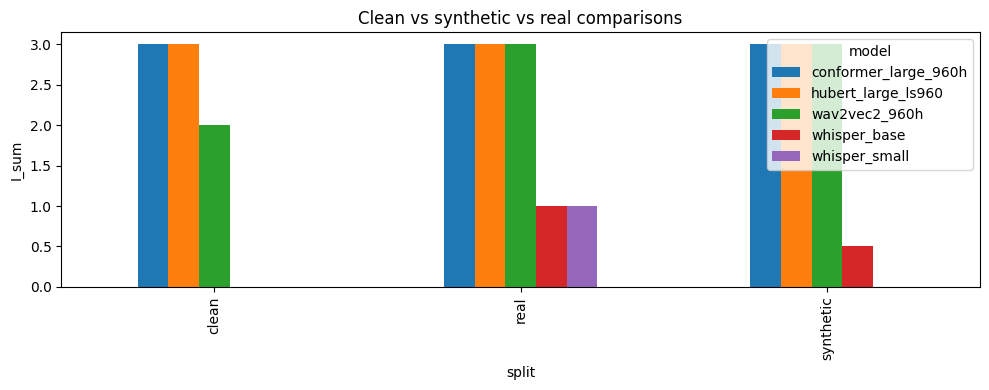

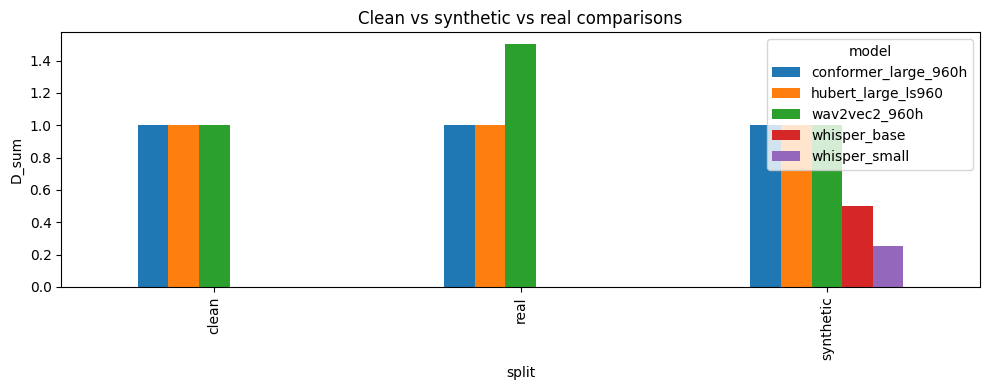

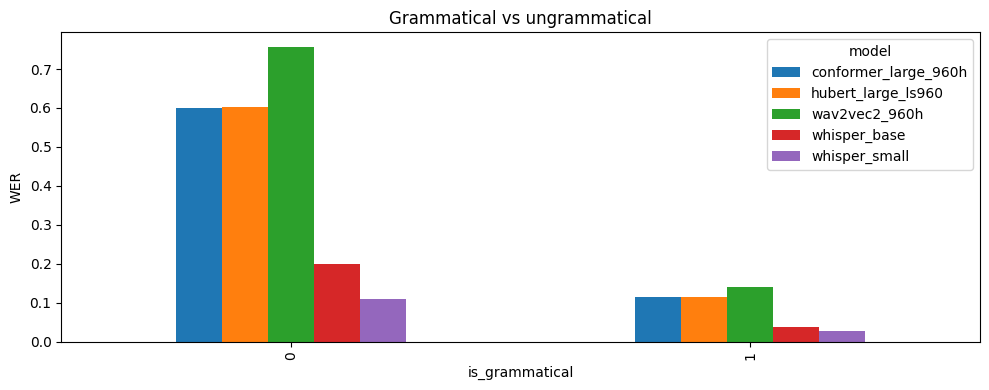

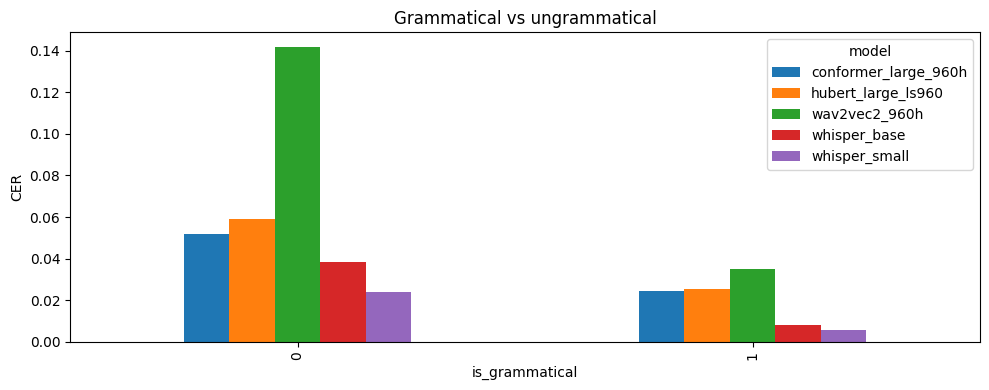

In [9]:
def summarize(results):
    return (results
            .groupby(["model","split","condition"], as_index=False)
            .agg(WER_mean=("WER","mean"),
                 WER_std=("WER","std"),
                 CER_mean=("CER","mean"),
                 S_sum=("S","sum"),
                 I_sum=("I","sum"),
                 D_sum=("D","sum")))

def plot_wer(summary, title):
    piv = summary.pivot_table(index="condition", columns="model", values="WER_mean")
    ax = piv.plot(kind="bar")
    ax.set_title(title)
    ax.set_ylabel("WER")
    plt.tight_layout()
    plt.show()

def compare_split(summary, title, value):
    piv = summary.pivot_table(index="split", columns="model", values=value)
    ax = piv.plot(kind="bar")
    ax.set_title(title)
    ax.set_ylabel(value)
    plt.tight_layout()
    plt.show()

def compare_grammar(summary, title, value):
    piv = summary.pivot_table(index="is_grammatical", columns="model", values=value)
    ax = piv.plot(kind="bar")
    ax.set_title(title)
    ax.set_ylabel(value)
    plt.tight_layout()
    plt.show()

# Example:
results = pd.read_csv(os.path.join(MET_DIR, "results.csv"))
summary = summarize(results)
summary.to_csv(os.path.join(MET_DIR, "summary.csv"), index=False)
# 1) WER by condition (per model)
plot_wer(summary[summary.split=="synthetic"], "Synthetic Conditions — WER")

# 2) Clean vs synthetic vs real comparisons
metrics2 = ["WER_mean","CER_mean", "S_sum", "I_sum", "D_sum"]
for metric in metrics2:
    compare_split(summary,"Clean vs synthetic vs real comparisons",metric)

# 3) Grammatical vs ungrammatical comparisons
metrics3 = ["WER","CER"]
for metric in metrics3:
    compare_grammar(results,"Grammatical vs ungrammatical",metric)



## 11) Grammatical vs Ungrammatical Analysis 

Compute WER for:
- grammatical sentences (7)
- ungrammatical sentences (3)

Then compare: do ungrammatical sentences produce more **substitutions**?


In [18]:
def grammatical_analysis(results):
    grp = (results
           .groupby(["model","split","condition","is_grammatical"], as_index=False)
           .agg(WER_mean=("WER","mean"),
                S_sum=("S","sum"),
                I_sum=("I","sum"),
                D_sum=("D","sum")))
    return grp

# Example:
# ga = grammatical_analysis(results)
# ga.to_csv(os.path.join(MET_DIR, "grammatical_vs_ungrammatical.csv"), index=False)
# ga.head()

def grammatical_analysis_with_corpus_wer(results):
    df = results.copy()
    
    # count reference words
    df["ref_len"] = df["ref"].str.split().apply(len)

    grp = (df
           .groupby(["model","split","condition","is_grammatical"], as_index=False)
           .agg(
                S_sum=("S","sum"),
                I_sum=("I","sum"),
                D_sum=("D","sum"),
                N_words=("ref_len","sum"),
                n_sentences=("sentence_id","count"),
                WER_mean=("WER","mean")
           ))
    
    # compute corpus-level WER
    grp["WER_corpus"] = (grp["S_sum"] + grp["I_sum"] + grp["D_sum"]) / grp["N_words"]
    
    return grp

ga = grammatical_analysis_with_corpus_wer(results)
ga.head()

sub_comp = (ga
            .groupby("is_grammatical", as_index=False)
            .agg(total_S=("S_sum","sum"),
                 total_words=("N_words","sum")))

sub_comp["S_rate"] = sub_comp["total_S"] / sub_comp["total_words"]

print(sub_comp)

from scipy import stats

gram = results.loc[results["is_grammatical"]==1, "S"]
ungram = results.loc[results["is_grammatical"]==0, "S"]

t_stat, p_val = stats.ttest_ind(gram, ungram, equal_var=False)

print("Mean S (grammatical):", gram.mean())
print("Mean S (ungrammatical):", ungram.mean())
print("p-value:", p_val)

   is_grammatical  total_S  total_words    S_rate
0               0      124          420  0.295238
1               1      125         1995  0.062657
Mean S (grammatical): 0.5102040816326531
Mean S (ungrammatical): 1.180952380952381
p-value: 7.004158078805743e-08


## 12) Error examples (Qualitative analysis)

Pick at least **3-4** interesting failure cases and discuss in your report:
- Was the error due to noise masking?
- Were numbers/named entities misrecognized?
- Did ungrammatical structure confuse decoding?


In [12]:
def worst_cases(results, n=15):
    cols = ["model","split","condition","sentence_id","is_grammatical","WER","S","I","D","ref","hyp"]
    return results.sort_values("WER", ascending=False)[cols].head(n)

# Example:
worst_cases(results, n=20)


,model,split,condition,sentence_id,is_grammatical,WER,S,I,D,ref,hyp
349,whisper_small,real,env2,s10,0,1.333333,2,2,0,incompetent overpromise underdeliver,incompetent over promise under deliver.
279,whisper_base,real,env2,s10,0,1.333333,2,2,0,incompetent overpromise underdeliver,incompetent over promise under deliver.
29,conformer_large_960h,synthetic,noise_traffic_snr20,s10,0,1.333333,2,2,0,incompetent overpromise underdeliver,INCOMPETENT OVER PROMISE UNDER DELIVER
259,whisper_base,synthetic,noise_white_snr20,s10,0,1.333333,2,2,0,incompetent overpromise underdeliver,"incompetent, over promise, under deliver."
19,conformer_large_960h,synthetic,noise_traffic_snr10,s10,0,1.333333,2,2,0,incompetent overpromise underdeliver,INCOMPETENT OVER PROMISE UNDER DELIVER
199,wav2vec2_960h,real,env1,s10,0,1.333333,2,2,0,incompetent overpromise underdeliver,INCOMPETENT OVER PROMISE UNDER DELIVER
209,wav2vec2_960h,real,env2,s10,0,1.333333,2,2,0,incompetent overpromise underdeliver,INCOMPETENT OVER PROMISE UNDER DELIVER
179,wav2vec2_960h,synthetic,noise_white_snr10,s10,0,1.333333,2,2,0,incompetent overpromise underdeliver,INCOMPETENT OVER PROMISE UNDER DELIVER
39,conformer_large_960h,synthetic,noise_white_snr10,s10,0,1.333333,2,2,0,incompetent overpromise underdeliver,INCOMPETENT OVER PROMISE UNDER DELIVER
189,wav2vec2_960h,synthetic,noise_white_snr20,s10,0,1.333333,2,2,0,incompetent overpromise underdeliver,INCOMPETENT OVER PROMISE UNDER DELIVER
